# Employee Attrition Prediction using Machine Learning

Employee attrition can negatively impact productivity, increase hiring costs, and disrupt organizational performance. In this project, I use the IBM HR Analytics Employee Attrition dataset to predict whether an employee is likely to leave a company.
The project includes data cleaning, exploratory data analysis (EDA), feature engineering, preprocessing, and Logistic Regression modeling. Since employee attrition data is imbalanced, model performance is improved using class balancing and threshold tuning. The final model prioritizes identifying employees at risk of leaving by optimizing recall, making it more suitable for HR retention strategies.


In [117]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [86]:
df=pd.read_csv("C:\employee attrition prediction\data\WA_Fn-UseC_-HR-Employee-Attrition.csv")
df

<>:1: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<>:1: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
C:\Users\Sanjana Desigan\AppData\Local\Temp\ipykernel_19784\2326776537.py:1: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
  df=pd.read_csv("C:\employee attrition prediction\data\WA_Fn-UseC_-HR-Employee-Attrition.csv")


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


In [87]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='str')

In [88]:
df.shape

(1470, 35)

In [89]:
df.info

<bound method DataFrame.info of       Age Attrition     BusinessTravel  DailyRate              Department  \
0      41       Yes      Travel_Rarely       1102                   Sales   
1      49        No  Travel_Frequently        279  Research & Development   
2      37       Yes      Travel_Rarely       1373  Research & Development   
3      33        No  Travel_Frequently       1392  Research & Development   
4      27        No      Travel_Rarely        591  Research & Development   
...   ...       ...                ...        ...                     ...   
1465   36        No  Travel_Frequently        884  Research & Development   
1466   39        No      Travel_Rarely        613  Research & Development   
1467   27        No      Travel_Rarely        155  Research & Development   
1468   49        No  Travel_Frequently       1023                   Sales   
1469   34        No      Travel_Rarely        628  Research & Development   

      DistanceFromHome  Education Education

In [90]:
df.describe

<bound method NDFrame.describe of       Age Attrition     BusinessTravel  DailyRate              Department  \
0      41       Yes      Travel_Rarely       1102                   Sales   
1      49        No  Travel_Frequently        279  Research & Development   
2      37       Yes      Travel_Rarely       1373  Research & Development   
3      33        No  Travel_Frequently       1392  Research & Development   
4      27        No      Travel_Rarely        591  Research & Development   
...   ...       ...                ...        ...                     ...   
1465   36        No  Travel_Frequently        884  Research & Development   
1466   39        No      Travel_Rarely        613  Research & Development   
1467   27        No      Travel_Rarely        155  Research & Development   
1468   49        No  Travel_Frequently       1023                   Sales   
1469   34        No      Travel_Rarely        628  Research & Development   

      DistanceFromHome  Education Educati

In [91]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='str')

In [92]:
df.isnull().sum()
#so none of the values are empty 

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [93]:
df["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

EDA

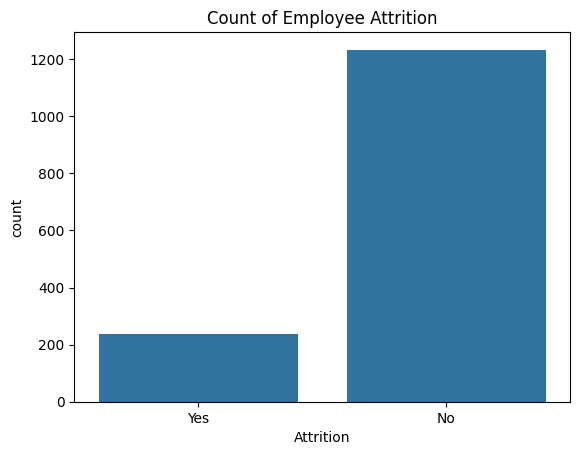

In [94]:
sns.countplot(x="Attrition",data=df)
plt.title("Count of Employee Attrition")
plt.show()

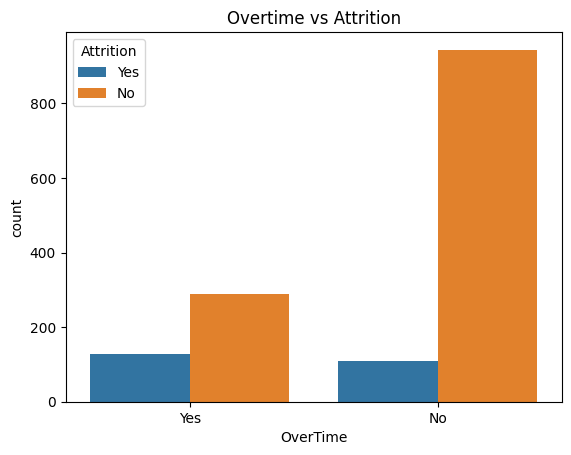

In [95]:
sns.countplot(x="OverTime", hue="Attrition",data=df)
plt.title("Overtime vs Attrition")
plt.show()

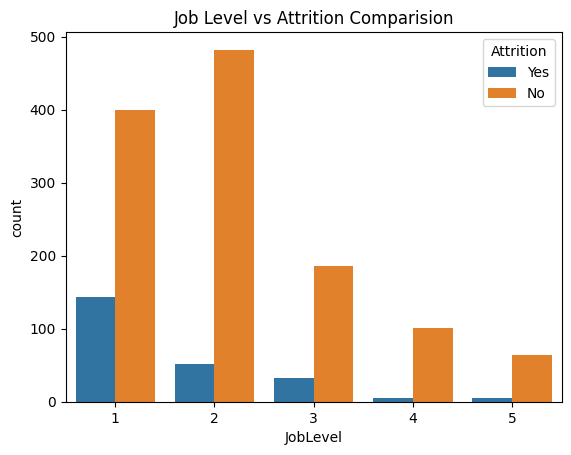

In [96]:
sns.countplot(x="JobLevel", hue="Attrition", data=df)
plt.title("Job Level vs Attrition Comparision")
plt.show()

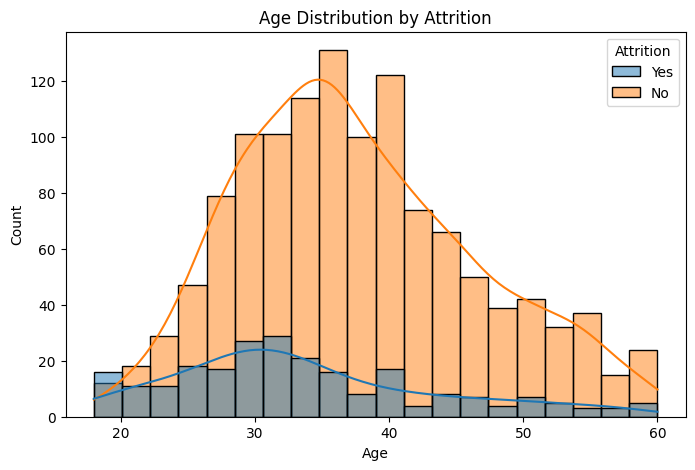

In [97]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="Age", hue="Attrition", bins=20, kde=True)
plt.title("Age Distribution by Attrition")
plt.show()

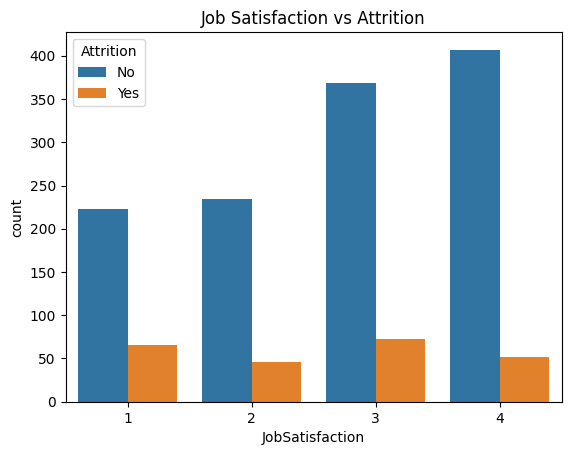

In [98]:
sns.countplot(x="JobSatisfaction", hue="Attrition", data=df)
plt.title("Job Satisfaction vs Attrition")
plt.show()

Feature Scaling / Engineering

In [99]:
df["IncomeCategory"] = pd.cut(df["MonthlyIncome"], bins=[0, 4000, 8000, 20000], labels=["Low", "Medium", "High"])

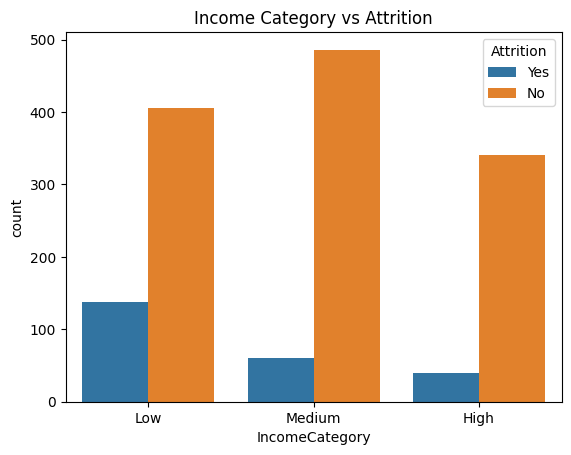

In [100]:
sns.countplot(x="IncomeCategory", hue="Attrition",data=df)
plt.title("Income Category vs Attrition")
plt.show()

In [101]:
pd.crosstab(df["IncomeCategory"],df["Attrition"], normalize="index") * 100

Attrition,No,Yes
IncomeCategory,,
Low,74.769797,25.230203
Medium,89.010989,10.989011
High,89.501312,10.498688


In [102]:
df = pd.read_csv(r"C:\employee attrition prediction\data\WA_Fn-UseC_-HR-Employee-Attrition.csv")
df["Attrition"] = df["Attrition"].map({
    "Yes": 1,
    "No": 0
})
df["OverTime"] = df["OverTime"].map({
    "Yes": 1,
    "No": 0
})
df["Gender"] = df["Gender"].map({
    "Male": 1,
    "Female": 0
})
df["IncomeCategory"] = pd.cut(
    df["MonthlyIncome"],
    bins=[0, 4000, 8000, 20000],
    labels=["Low", "Medium", "High"]
)
df["IncomeCategory"] = df["IncomeCategory"].map({
    "Low": 0,
    "Medium": 1,
    "High": 2
}).astype(int)

# One-hot encoding
df = pd.get_dummies(
    df,
    columns=[
        "BusinessTravel",
        "Department",
        "EducationField",
        "JobRole",
        "MaritalStatus"
    ],
    drop_first=True
)

In [103]:
df.drop(columns=["Over18"], inplace=True)

In [104]:
df.isnull().sum().sum()

np.int64(0)

In [105]:
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

In [106]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [107]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

c:\Users\Sanjana Desigan\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [108]:
model.score(X_test, y_test)

0.8639455782312925

In [109]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.98      0.93       255
           1       0.43      0.08      0.13        39

    accuracy                           0.86       294
   macro avg       0.65      0.53      0.53       294
weighted avg       0.82      0.86      0.82       294



In [110]:
from sklearn.linear_model import LogisticRegression

model_balanced = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model_balanced.fit(X_train, y_train)

y_pred_balanced = model_balanced.predict(X_test)

c:\Users\Sanjana Desigan\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [111]:
print(classification_report(
    y_test,
    y_pred_balanced
))

              precision    recall  f1-score   support

           0       0.94      0.68      0.79       255
           1       0.26      0.72      0.38        39

    accuracy                           0.69       294
   macro avg       0.60      0.70      0.58       294
weighted avg       0.85      0.69      0.74       294



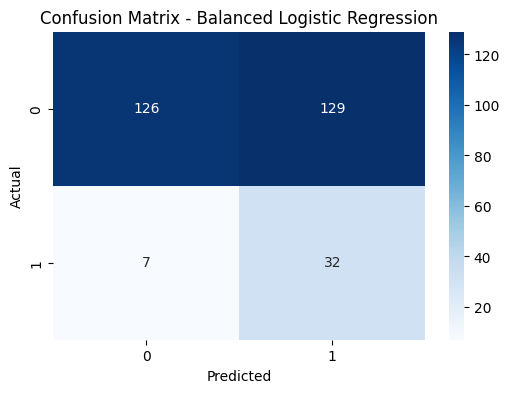

In [112]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(
    y_test,
    y_pred_35
)
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(
    "Confusion Matrix - Balanced Logistic Regression"
)

plt.show()

In [113]:
y_prob = model_balanced.predict_proba(X_test)[:, 1]
y_pred_35 = (y_prob >= 0.35).astype(int)

In [114]:
print(classification_report(
    y_test,
    y_pred_35
))


              precision    recall  f1-score   support

           0       0.95      0.49      0.65       255
           1       0.20      0.82      0.32        39

    accuracy                           0.54       294
   macro avg       0.57      0.66      0.48       294
weighted avg       0.85      0.54      0.61       294



In [115]:
comparison = pd.DataFrame({
    "Model": [
        "Basic Logistic Regression",
        "Balanced Logistic Regression",
        "Threshold Tuned (0.35)"
    ],
    "Accuracy": [
        0.86,
        0.69,
        0.54
    ],
    "Recall (Attrition)": [
        0.08,
        0.72,
        0.82
    ],
    "Precision (Attrition)": [
        0.43,
        0.26,
        0.20
    ]
})

comparison

,Model,Accuracy,Recall (Attrition),Precision (Attrition)
0,Basic Logistic Regression,0.86,0.08,0.43
1,Balanced Logistic Regression,0.69,0.72,0.26
2,Threshold Tuned (0.35),0.54,0.82,0.20


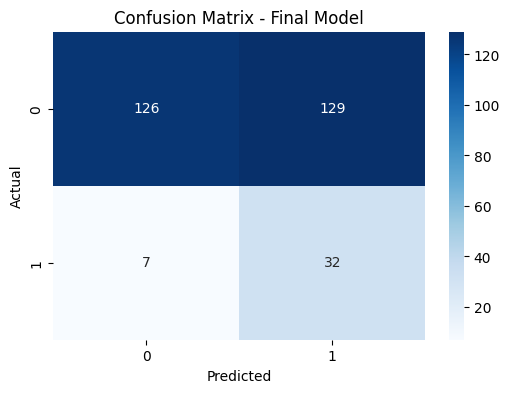

In [116]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred_35
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(
    "Confusion Matrix - Final Model"
)

plt.show()

## Conclusion
In this project, I built an Employee Attrition Prediction Model using the IBM HR Analytics Employee Attrition dataset. The goal of the project was to predict whether an employee is likely to leave the company based on workplace, demographic, and job-related features.

During Exploratory Data Analysis (EDA), several important patterns were observed. Employees working overtime showed higher attrition, lower-income employees had a higher likelihood of leaving, and attrition was more common among employees in the age group of approximately 25–35 years. On the other hand, job satisfaction appeared to have a relatively smaller effect on employee attrition.
I first trained a basic Logistic Regression model, which achieved high accuracy but performed poorly in identifying employees who were actually leaving due to class imbalance in the dataset. To improve this, I implemented a balanced Logistic Regression model using class_weight="balanced".

Finally, I applied threshold tuning to better align the model with the business objective of employee retention. Since missing employee attrition is more costly than unnecessary HR check-ins, I prioritized recall over raw accuracy. The final model achieved approximately 82% recall for employee attrition, making it more effective at identifying employees who may leave the organization.

Overall, this project helped me understand the complete machine learning workflow, including data cleaning, EDA, preprocessing, feature engineering, logistic regression, model evaluation, class imbalance handling, and threshold tuning.